<a href="https://colab.research.google.com/github/ramadhanilatief/proyekdata_dqlab/blob/main/Data_Science_in_Telco_Data_Cleansing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction


## Latar Belakang

DQLab Telco merupakan perusahaan Telco yang sudah mempunyai banyak cabang tersebar dimana-mana. Sejak berdiri pada tahun 2019, DQLab Telco konsisten untuk memperhatikan *customer experience*-nya sehingga tidak akan ditinggalkan pelanggan.

Walaupun baru berumur 1 tahun lebih sedikit, DQLab Telco sudah mempunyai banyak pelanggan yang beralih langganan ke kompetitor. Pihak management ingin mengurangi jumlah pelanggan yang beralih (*churn*) dengan menggunakan *machine learning*.

Oleh karena itu, tim Data Scientist diminta untuk mempersiapkan data sekaligus membuat model prediksi yang tepat untuk menentukan pelanggan akan berhenti berlangganan (*churn*) atau tidak.

## Tugas dan Langkah

Sebagai seorang data *scientist*, kamu diminta untuk menyiapkan data sebelum dilakukan permodelan.

Pada tugas kali ini, kamu akan melakukan Data *Preprocessing* (Data *Cleansing*) bulan lalu, yakni Juni 2020.

Langkah yang akan dilakukan adalah,

* Mencari ID pelanggan (Nomor telepon) yang valid
* Mengatasi data-data yang masih kosong (*Missing Values*)
* Mengatasi Nilai-Nilai Pencilan (*Outlier*) dari setiap *Variable*
* Menstandardisasi Nilai dari *Variable*

## Data yang Digunakan

Untuk dataset yang digunakan sudah disediakan dalam format *csv*, silahkan baca melalui fungsi pandas di python df_load = pd.read_csv('https://storage.googleapis.com/dqlab-dataset/dqlab_telco.csv')


Untuk detail datanya adalah sebagai berikut:

* UpdatedAt Periode of Data taken
* customerID Customer ID
* gender Whether the customer is a male or a female (Male, Female)
* SeniorCitizen Whether the customer is a senior citizen or not (1, 0)
* Partner Whether the customer has a partner or not (Yes, No)
* Dependents Whether the customer has dependents or not (Yes, No)
* tenure Number of months the customer has stayed with the company
* PhoneService Whether the customer has a phone service or not (Yes, No)
* MultipleLines Whether the customer has multiple lines or not (Yes, No, No phone service)
* InternetService Customer's internet service provider (DSL, Fiber optic, No)
* OnlineSecurity Whether the customer has online security or not (Yes, No, No internet service)
* OnlineBackup Whether the customer has online backup or not (Yes, No, No internet service)
* DeviceProtection Whether the customer has device protection or not (Yes, No, No internet service)
* TechSupport Whether the customer has tech support or not (Yes, No, No internet service)
* StreamingTV Whether the customer has streaming TV or not (Yes, No, No internet service)
* StreamingMovies Whether the customer has streaming movies or not (Yes, No, No internet service)
* Contract The contract term of the customer (Month-to-month, One year, Two year)
* PaperlessBilling Whether the customer has paperless billing or not (Yes, No)
* PaymentMethod The customer's payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
* MonthlyCharges The amount charged to the customer monthly
* TotalCharges The total amount charged to the customer
* Churn Whether the customer churned or not (Yes or No)

# Import Library dan Dataset

Berdasarkan penjelasan mengenai library dan dataset yang akan digunakan, sekarang hal pertama yang akan kita lakukan adalah melakukan *import* library dan dataset ke dalam *workspace* kita.

In [1]:
#import library
import pandas as pd
pd.options.display.max_columns = 50

#import dataset
df_load = pd.read_csv('https://storage.googleapis.com/dqlab-dataset/dqlab_telco.csv')

#Tampilkan jumlah baris dan kolom
print(df_load.shape)

#Tampilkan 5 data teratas
print(df_load.head(5))

#Jumlah ID yang unik
print(df_load.customerID.nunique())

(7113, 22)
   UpdatedAt   customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     202006  45759018157  Female              0     Yes         No     1.0   
1     202006  45557574145    Male              0      No         No    34.0   
2     202006  45366876421    Male              0      No         No     2.0   
3     202006  45779536532    Male              0      No         No    45.0   
4     202006  45923787906  Female              0      No         No     2.0   

  PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup  \
0           No  No phone service             DSL             No          Yes   
1          Yes                No             DSL            Yes           No   
2          Yes                No             DSL            Yes          Yes   
3           No  No phone service             DSL            Yes           No   
4          Yes                No     Fiber optic             No           No   

  DeviceProtection TechSupport St

# Mencari Validitas ID Number Pelanggan

## Memfilter ID Number Pelanggan Format Tertentu

Mencari format ID Number (Phone Number) Pelanggan customerID yang benar, dengan kriteria:

* Panjang karakter adalah 11-12.
* Terdiri dari angka Saja, tidak diperbolehkan ada karakter selain angka.
* Diawali dengan angka 45 2 digit pertama.

In [2]:
df_load['valid_id'] = df_load['customerID'].astype(str).str.match(r'^45\d{9,10}$')

df_load = (df_load[df_load['valid_id'] == True]).drop('valid_id', axis=1)

print("Hasil jumlah ID Customer yang terfilter adalah", df_load['customerID'].count())

Hasil jumlah ID Customer yang terfilter adalah 7006


## Memfilter Duplikasi ID Number Pelanggan

Memastikan bahwa tidak ada Id Number pelanggan yang duplikat. Biasanya duplikasi ID number ini tipenya:

* Duplikasi dikarenakan *inserting* melebihi satu kali dengan nilai yang sama tiap kolomnya.
* Duplikasi dikarenakan *inserting* beda periode pengambilan data.

In [3]:
# Drop Duplicate Rows
df_load.drop_duplicates()
# Drop duplicate ID sorted by Periode
df_load = df_load.sort_values('UpdatedAt', ascending=False).drop_duplicates('customerID')
print('Hasil jumlah ID Customer yang sudah dihilangkan duplikasinya (distinct) adalah',df_load['customerID'].count())

Hasil jumlah ID Customer yang sudah dihilangkan duplikasinya (distinct) adalah 6993


Berdasarkan hasil tersebut, terdapat perbedaan jumlah nomor ID dari data pertama kali di-*load* sampai dengan hasil akhir. Jumlah *row* data ketika pertama kali di-*load* ada sebanyak 7113 *rows* dan 22 *columns* dengan 7017 jumlah ID yang *unique*. Kemudian setelah dicek validitas dari ID pelanggan, maka tersisa 6993 *rows* data.

# Mengatasi Missing Values

## Mengatasi Missing Values dengan Penghapusan Rows

Selanjutnya kita akan menghapus *rows* dari data-data yang tidak terdeteksi apakah dia *churn* atau tidak. Diasumsikan data *modeller* hanya mau menerima data yang benar ada *flag churn*-nya atau tidak.

In [4]:
print('Total missing values data dari kolom Churn', df_load['Churn'].isnull().sum())
# Dropping all Rows with spesific column (churn)
df_load.dropna(subset = ['Churn'], inplace = True)
print('Total Rows dan kolom Data setelah dihapus data Missing Values adalah', df_load.shape)

Total missing values data dari kolom Churn 43
Total Rows dan kolom Data setelah dihapus data Missing Values adalah (6950, 22)


## Mengatasi Missing Values dengan Pengisian Nilai tertentu

Selain dengan menghapus rows dari data, menangani *missing values* bisa menggunakan nilai tertentu. Diasumsikan data *modeller* meminta pengisian *missing values* dengan kriteria berikut:

* Tenure pihak data *modeller* meminta setiap rows yang memiliki  *missing values* untuk lama berlangganan di isi dengan 11.
* *Variable* yang bersifat *numeric* selain Tenure di isi dengan median dari masing-masing *variable* tersebut.

Tentukan:

* Apakah masih ada data yang *missing values*
* Jumlah *missing values* dari masing-masing *variable*
* Tangani *missing values*-nya

In [5]:
print('Status Missing Values :',df_load.isnull().values.any())
print('\nJumlah Missing Values masing-masing kolom, adalah:')
print(df_load.isnull().sum().sort_values(ascending=False))

#handling missing values Tenure fill with 11
df_load['tenure'].fillna(11, inplace=True)

# Loop untuk mengisi missing values pada kolom numeric selain tenure
# Gunakan nama variabel median (bukan median_val, x, dll) agar sesuai instruksi dan bisa terbaca auto-grader
for col_name in list(['MonthlyCharges', 'TotalCharges']):
        median = df_load[col_name].median()
        df_load[col_name].fillna(median, inplace=True)

print('\nJumlah Missing Values setelah di imputer datanya, adalah:')
print(df_load.isnull().sum().sort_values(ascending=False))

Status Missing Values : True

Jumlah Missing Values masing-masing kolom, adalah:
tenure              99
MonthlyCharges      26
TotalCharges        15
gender               0
UpdatedAt            0
customerID           0
Dependents           0
Partner              0
SeniorCitizen        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
MultipleLines        0
InternetService      0
TechSupport          0
DeviceProtection     0
StreamingTV          0
StreamingMovies      0
PaperlessBilling     0
Contract             0
PaymentMethod        0
Churn                0
dtype: int64

Jumlah Missing Values setelah di imputer datanya, adalah:
UpdatedAt           0
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMo

/tmp/ipykernel_15438/4075185506.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_load['tenure'].fillna(11, inplace=True)
/tmp/ipykernel_15438/4075185506.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

Setelah kita analisis lebih lanjut, ternyata masih ada *missing values* dari data yang kita sudah validkan Id Number pelanggannya. *Missing values* terdapat pada kolom Churn, tenure, MonthlyCharges & TotalCharges. Setelah kita tangani dengan cara penghapusan *rows* dan pengisian *rows* dengan nilai tertentu, terbukti sudah tidak ada *missing values* lagi pada data, terbukti dari jumlah *missing values* masing-masing *variable* yang bernilai 0.

# Mengatasi Outlier

## Mendeteksi Adanya Outlier Menggunakan Boxplot

Mendeteksi pencilan dari suatu nilai (*outlier*) salah satunya bisa melihat plot dari data tersebut menggunakan *boxplot*. *Boxplot* merupakan ringkasan distribusi sampel yang disajikan secara grafis yang bisa menggambarkan bentuk distribusi data (*skewness*), ukuran tendensi sentral dan ukuran penyebaran (keragaman).

Melalui penggunaan fungsi describe() pada kolom tenure, MonthlyCharges, dan TotalCharges ini kita hanya memperoleh statistik deskriptif ketiga kolom ini. Agar *outlier* pada ketiga kolom ini dapat dideteksi maka kamu diminta untuk memvisualisasikannya menggunakan *boxplot*-nya. Setiap satu *boxplot* ada di satu *canvas figure*.




Persebaran data sebelum ditangani Outlier: 
            tenure  MonthlyCharges  TotalCharges
count  6950.000000     6950.000000   6950.000000
mean     32.477266       65.783741   2305.083460
std      25.188910       50.457871   2578.651143
min       0.000000        0.000000     19.000000
25%       9.000000       36.462500    406.975000
50%      29.000000       70.450000   1400.850000
75%      55.000000       89.850000   3799.837500
max     500.000000     2311.000000  80000.000000


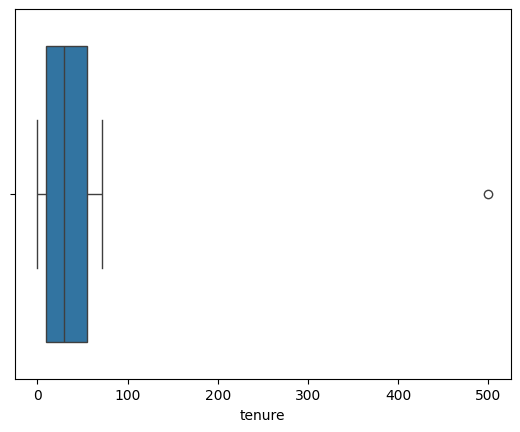

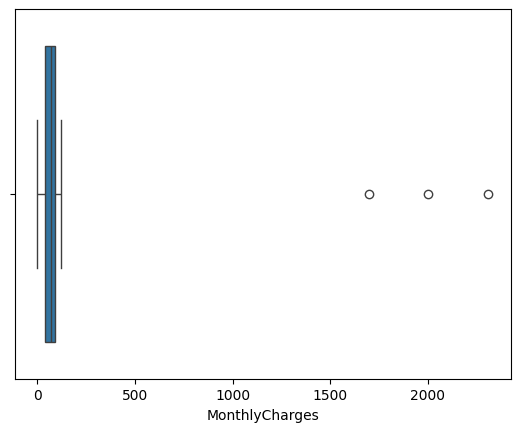

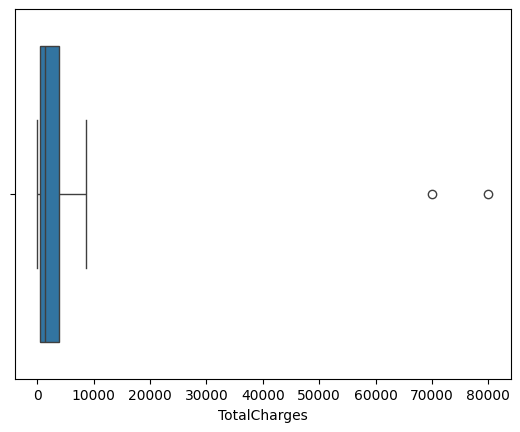

In [6]:
print('\nPersebaran data sebelum ditangani Outlier: ')
print(df_load[['tenure','MonthlyCharges','TotalCharges']].describe())

# Creating Box Plot
import matplotlib.pyplot as plt
import seaborn as sns

# Misal untuk kolom tenure
plt.figure()
sns.boxplot(x=df_load['tenure'])
plt.show()

# dan seterusnya untuk kedua kolom yang tersisa secara berurut
plt.figure()
sns.boxplot(x=df_load['MonthlyCharges'])
plt.show()

plt.figure()
sns.boxplot(x=df_load['TotalCharges'])
plt.show()

## Mengatasi Outlier

Setelah kita mengetahui *variable* mana saja yang terdapat pencilan (*outlier*), selanjutnya kita akan atasi *outlier* dengan menggunakan metode *interquartile range* (IQR).

Tentukan:
* Nilai *minimum* dan *maximum* data di tolerir
* Ubah nilai yang di luar *range minimum* & *maximum* ke dalam nilai *minimum* dan *maximum*

In [7]:
Q1 = df_load[['tenure','MonthlyCharges','TotalCharges']].quantile(0.25)
Q3 = df_load[['tenure','MonthlyCharges','TotalCharges']].quantile(0.75)

IQR = Q3 - Q1
maximum = Q3 + 1.5 * IQR
print('Nilai Maximum dari masing-masing Variable adalah:')
print(maximum)
minimum = Q1 - 1.5 * IQR
print('\nNilai Minimum dari masing-masing Variable adalah:')
print(minimum)

columns_to_handle = ['tenure','MonthlyCharges','TotalCharges']

more_than = df_load[columns_to_handle] > maximum
lower_than = df_load[columns_to_handle] < minimum

df_load[columns_to_handle] = df_load[columns_to_handle].mask(more_than, maximum, axis=1)
df_load[columns_to_handle] = df_load[columns_to_handle].mask(lower_than, minimum, axis=1)

print('\nPersebaran data setelah ditangani Outlier: ')
print(df_load[['tenure','MonthlyCharges','TotalCharges']].describe())

Nilai Maximum dari masing-masing Variable adalah:
tenure             124.00000
MonthlyCharges     169.93125
TotalCharges      8889.13125
dtype: float64

Nilai Minimum dari masing-masing Variable adalah:
tenure             -60.00000
MonthlyCharges     -43.61875
TotalCharges     -4682.31875
dtype: float64

Persebaran data setelah ditangani Outlier: 
            tenure  MonthlyCharges  TotalCharges
count  6950.000000     6950.000000   6950.000000
mean     32.423165       64.992201   2286.058750
std      24.581073       30.032040   2265.702553
min       0.000000        0.000000     19.000000
25%       9.000000       36.462500    406.975000
50%      29.000000       70.450000   1400.850000
75%      55.000000       89.850000   3799.837500
max     124.000000      169.931250   8889.131250


Dari ketiga *boxplot* dengan *variable* 'tenure','MonthlyCharges' & 'TotalCharges' terlihat jelas bahwasannya ada *outlier*. Hal ini bisa diidentifikasi dari adanya titik-titik yang berada jauh dari gambar *boxplot*-nya. Kemudian kalau kita liat persebaran datanya dari kolom *max*-nya juga ada nilai yang sangat tinggi sekali.

Kemudian nilai *outlier* tersebut ditangani dengan cara mengubah nilainya ke nilai *maximum* & *minimum* dari *interquartile range* (IQR). Setelah ditangani *outlier*-nya, dan dilihat perseberan datanya, terlihat sudah tidak ada lagi nilai yang *outlier*.

# Menstandarisasi Nilai

## Mendeteksi Nilai yang tidak Standar

Mendeteksi apakah ada nilai-nilai dari *variable* kategorik yang tidak *standard*. Hal ini biasanya terjadi dikarenakan kesalahan *input* data. Perbedaan istilah menjadi salah satu faktor yang sering terjadi, untuk itu dibutuhkan standardisasi dari data yang sudah ter-*input*.

In [8]:
for col_name in list(['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','Churn']):
	print('\nUnique Values Count Before Standardized Variable', col_name)
	print(df_load[col_name].value_counts())


Unique Values Count Before Standardized Variable gender
gender
Male         3499
Female       3431
Wanita         14
Laki-Laki       6
Name: count, dtype: int64

Unique Values Count Before Standardized Variable SeniorCitizen
SeniorCitizen
0    5822
1    1128
Name: count, dtype: int64

Unique Values Count Before Standardized Variable Partner
Partner
No     3591
Yes    3359
Name: count, dtype: int64

Unique Values Count Before Standardized Variable Dependents
Dependents
No     4870
Yes    2060
Iya      20
Name: count, dtype: int64

Unique Values Count Before Standardized Variable PhoneService
PhoneService
Yes    6281
No      669
Name: count, dtype: int64

Unique Values Count Before Standardized Variable MultipleLines
MultipleLines
No                  3346
Yes                 2935
No phone service     669
Name: count, dtype: int64

Unique Values Count Before Standardized Variable InternetService
InternetService
Fiber optic    3057
DSL            2388
No             1505
Name: count, dtyp

## Menstandarisasi Variable Kategorik

Setelah kita mengetahui *variable* mana saja yang ada nilai tidak *standard*, maka kita *standard*-kan dengan pola terbanyaknya, dengan syarat tanpa mengubah maknanya. Contoh : Iya -> Yes Kemudian liat kembali *unique values* dari masing-masing *variable* yang sudah di ubah.

In [9]:
df_load = df_load.replace(['Wanita','Laki-Laki','Churn','Iya'],['Female','Male','Yes','Yes'])

#Loop
for col_name in list(['gender','Dependents','Churn']):
	print('\nUnique Values Count After Standardized Variable', col_name)
	print(df_load[col_name].value_counts())


Unique Values Count After Standardized Variable gender
gender
Male      3505
Female    3445
Name: count, dtype: int64

Unique Values Count After Standardized Variable Dependents
Dependents
No     4870
Yes    2080
Name: count, dtype: int64

Unique Values Count After Standardized Variable Churn
Churn
No     5114
Yes    1836
Name: count, dtype: int64


Ketika kita amati lebih jauh dari jumlah *unique value* dari masing-masing *variable* kategorik, terlihat jelas bahwa ada beberapa *variable* yang tidak standar. *Variable* itu adalah:

* Gender (Female, Male, Wanita, Laki-Laki), yang bisa di-*standard*-kan nilainya menjadi (Female, Male) karena mempunyai makna yang sama.
* Dependents (Yes, No, Iya), yang bisa di-*standard*-kan nilainya menjadi (Yes, No) karena mempunyai makna yang sama.
* Churn (Yes, No, Churn), yang bisa di-*standard*-kan nilainya menjadi (Yes, No) karena mempunyai makna yang sama.

Setelah kita *standard*-kan nilainya, dan kita amati kembali bentuk datanya, sudah terstandar dengan baik untuk *unique value*-nya.